## Speeches targeted for the general public

In [1]:
! pip install openpyxl
! pip install wordcloud

In [2]:
import openpyxl as open 
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt 
import nltk
from nltk.corpus import stopwords


In [3]:
# Charger le fichier Excel
data = pd.read_excel(
    "Database_centralbank_comm.xlsx",  
    header=None,                      
    names=["Institution", "Date", "Speech"]        
)

FileNotFoundError: [Errno 2] No such file or directory: 'Database_centralbank_comm.xlsx'

In [6]:
data = data.iloc[1:].reset_index(drop=True)
data.head()

,Institution,Date,Speech
0,ECB,2025-12-18 00:00:00,We kept our key interest rates unchanged. We d...
1,ECB,2025-10-30 00:00:00,We kept our key interest rates unchanged We di...
2,ECB,2025-09-11 00:00:00,We kept our key interest rates unchanged We di...
3,ECB,2025-07-24 00:00:00,We kept our key interest rates unchanged\n\nWe...
4,ECB,2025-06-05 00:00:00,We cut our key interest rates by 0.25 percenta...


In [8]:
# Print examples of the articles
pd.set_option('display.max_colwidth', None)
# YOUR CODE HERE
data.sample(5, random_state=42)

Institution                 Date  \
4          ECB  2025-06-05 00:00:00   
63         BoE  2022-08-04 00:00:00   
18         ECB  2023-09-14 00:00:00   
0          ECB  2025-12-18 00:00:00   
28         ECB  2022-06-09 00:00:00   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


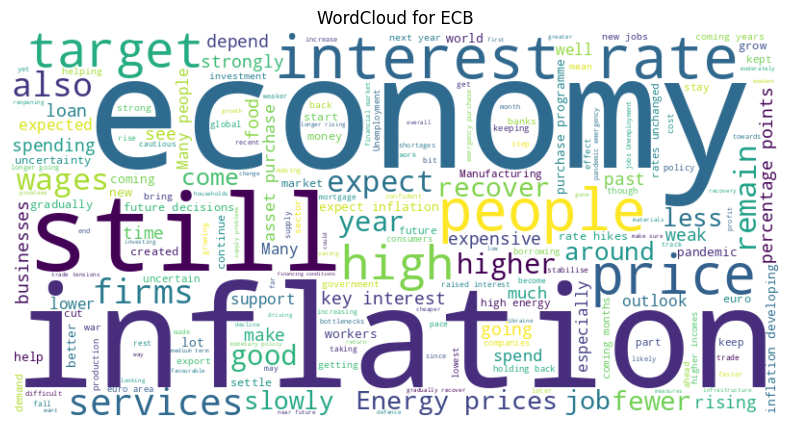

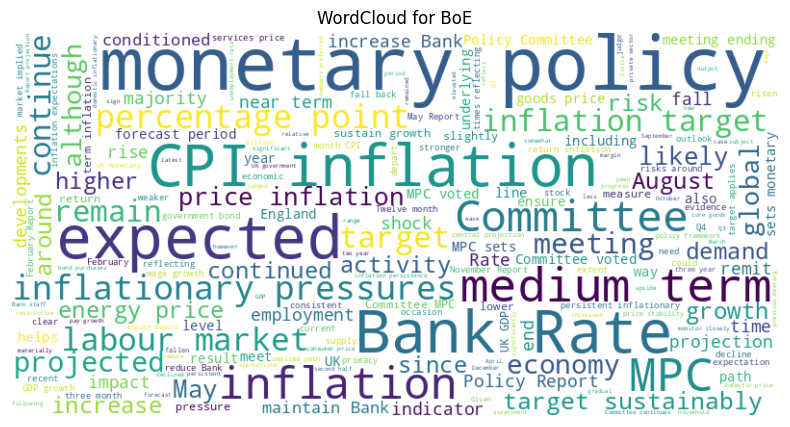

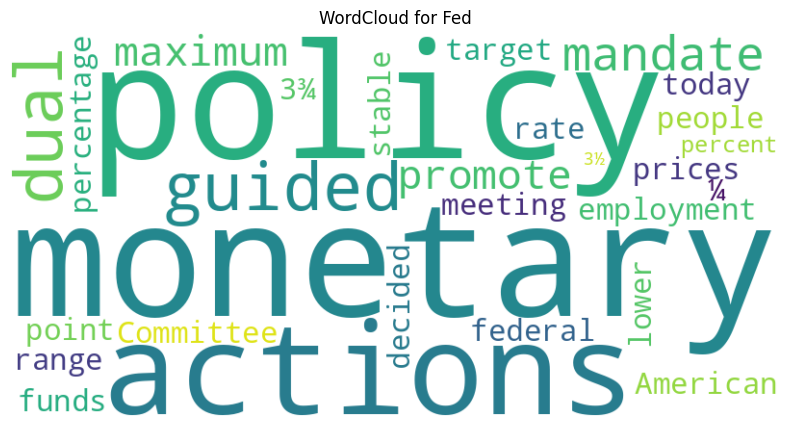

In [ ]:
nltk.download('stopwords')
# Stopwords en anglais
stop_words = set(stopwords.words('english'))


for cat in ['ECB', 'BoE', 'Fed']:
    
    # Sélection des discours par institution
    text_cat = " ".join(
        data.loc[data["Institution"] == cat, "Speech"].dropna()
    )
    
    # WordCloud
    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        stopwords=stop_words,
        max_words=200
    ).generate(text_cat)
    
    # Plot
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud for {cat}")
    plt.show()


## Classic speeches 
This dataset comes from this article : Campiglio, E., Deyris, J., Romelli, D. and Scalisi, G., 2025. Warning words in a warming world: Central bank communication and climate change. European Economic Review [Open Access], Vol 178.

In [3]:
# Stockage et lecture des fichiers
import os
import requests
import s3fs

In [4]:
# Database of Campiglio, Deyris, Romelli and Scalisi (saved in the SSP Cloud, too heavy for github) :
MY_BUCKET = "lelkamel"
fs = s3fs.S3FileSystem(
    client_kwargs={"endpoint_url": "https://minio.lab.sspcloud.fr"}
)

files_url = f"{MY_BUCKET}/"

fs.get(f"{MY_BUCKET}/","", recursive=True)

# Lecture
specialized_speeches = pd.read_csv("CBS_dataset_v1.0.csv")

In [ ]:
specialized_speeches.info()

In [6]:
specialized_speeches["Country"].unique()

array(['ABW', 'AGO', 'ALB', 'ARE', 'ARG', 'ARM', 'AUS', 'AUT', 'BDI',
       'BEL', 'BGD', 'BGR', 'BHR', 'BHS', 'BIH', 'BLZ', 'BRA', 'BRB',
       'BWA', 'CAN', 'CHE', 'CHL', 'CHN', 'COL', 'COM', 'CPV', 'CRI',
       'CUW', 'CYP', 'CZE', 'DEU', 'DNK', 'DOM', 'DZA', 'ECB', 'ESP',
       'EST', 'FIN', 'FJI', 'FRA', 'GBR', 'GHA', 'GRC', 'GUY', 'HKG',
       'HRV', 'HTI', 'HUN', 'IDN', 'IND', 'IRL', 'ISL', 'ISR', 'ITA',
       'JAM', 'JPN', 'KAZ', 'KEN', 'KHM', 'KOR', 'XKX', 'KWT', 'LBR',
       'LKA', 'LSO', 'LTU', 'LUX', 'LVA', 'MAR', 'MDV', 'MEX', 'MKD',
       'MLT', 'MNE', 'MOZ', 'MRT', 'MUS', 'MWI', 'MYS', 'NAM', 'NGA',
       'NIC', 'NLD', 'NOR', 'NPL', 'NZL', 'OECS', 'PAK', 'PHL', 'PNG',
       'POL', 'PRT', 'PRY', 'QAT', 'USA', 'SWE', 'TUR', 'SGP', 'ZAF',
       'THA', 'TTO', 'ZMB', 'SVK', 'SLE', 'SRB', 'ECU', 'ROU', 'UGA',
       'CYM', 'SAU', 'GMB', 'VUT', 'SLB', 'MAC', 'RUS', 'WSM', 'JOR',
       'BOL', 'GTM', 'URY', 'TZA', 'SVN', 'SYC', 'UKR', 'RWA', 'SLV',
       'STP', 'SUR'

In [7]:
specialized_speeches["Date"] = pd.to_datetime(
    specialized_speeches["Date"]
)

In [8]:
countries_selected = [
    "USA",
    "GBR",
    "ECB"
]

specialized_speeches_filtered = specialized_speeches[
    specialized_speeches["Country"].isin(countries_selected)
]
# Dimensions (lignes, colonnes)
specialized_speeches_filtered.shape

print(f"Nombre de discours : {specialized_speeches_filtered.shape[0]}")
print(f"Nombre de variables : {specialized_speeches_filtered.shape[1]}")


Nombre de discours : 10626
Nombre de variables : 15


In [9]:
specialized_speeches_filtered.head()

,URL,PDF,Title,Subtitle,Date,Authorname,Role,Gender,CentralBank,Country,text,text_original,Filename,Language,Source
2976,https://www.ecb.europa.eu/press/key/date/2000/...,NaN,One year with the euro,"Speech delivered by Dr Sirkka Hmlinen, Mem...",2000-01-08,Sirkka Hmlinen,Board member,Female,European Central Bank,ECB,One year with the euro Speech delivered by Dr ...,NaN,ecb_000108.en,English,CB websites
2977,https://www.ecb.europa.eu/press/key/date/2000/...,NaN,Opening Remarks at a Hearing of the Committee ...,"Professor Otmar Issing, Member of the Board o...",2000-01-10,Otmar Issing,Board member,Male,European Central Bank,ECB,Opening Remarks at a Hearing of the Committee ...,NaN,ecb_000110.en,English,CB websites
2978,https://www.ecb.europa.eu/press/key/date/2000/...,NaN,The international impact of the euro,"Speech delivered by Christian Noyer, Vice...",2000-01-13,Christian Noyer,Deputy Governor,Male,European Central Bank,ECB,The international impact of the euro Speech de...,NaN,ecb_000113.en,English,BIS
2979,https://www.ecb.europa.eu/press/key/date/2000/...,NaN,The role of the central bank in encouraging an...,"Speech given by Christian Noyer, Vice-Pres...",2000-01-21,Christian Noyer,Deputy Governor,Male,European Central Bank,ECB,The role of the central bank in encouraging an...,NaN,ecb_000121.en,English,BIS
2980,https://www.ecb.europa.eu/press/key/date/2000/...,NaN,The euro area - first experience and perspectives,"by Professor Otmar Issing, Member of the Boar...",2000-01-26,Otmar Issing,Board member,Male,European Central Bank,ECB,The euro area - first experience and perspecti...,NaN,ecb_000126.en,English,CB websites


In [9]:
specialized_speeches_filtered.to_csv(
    "central_bank_speeches_2018_US_UK_EU.csv",
    index=False,
    encoding="utf-8"
)

### Some descriptive statistics

Do some instutions speak more than others ? Who speaks ?

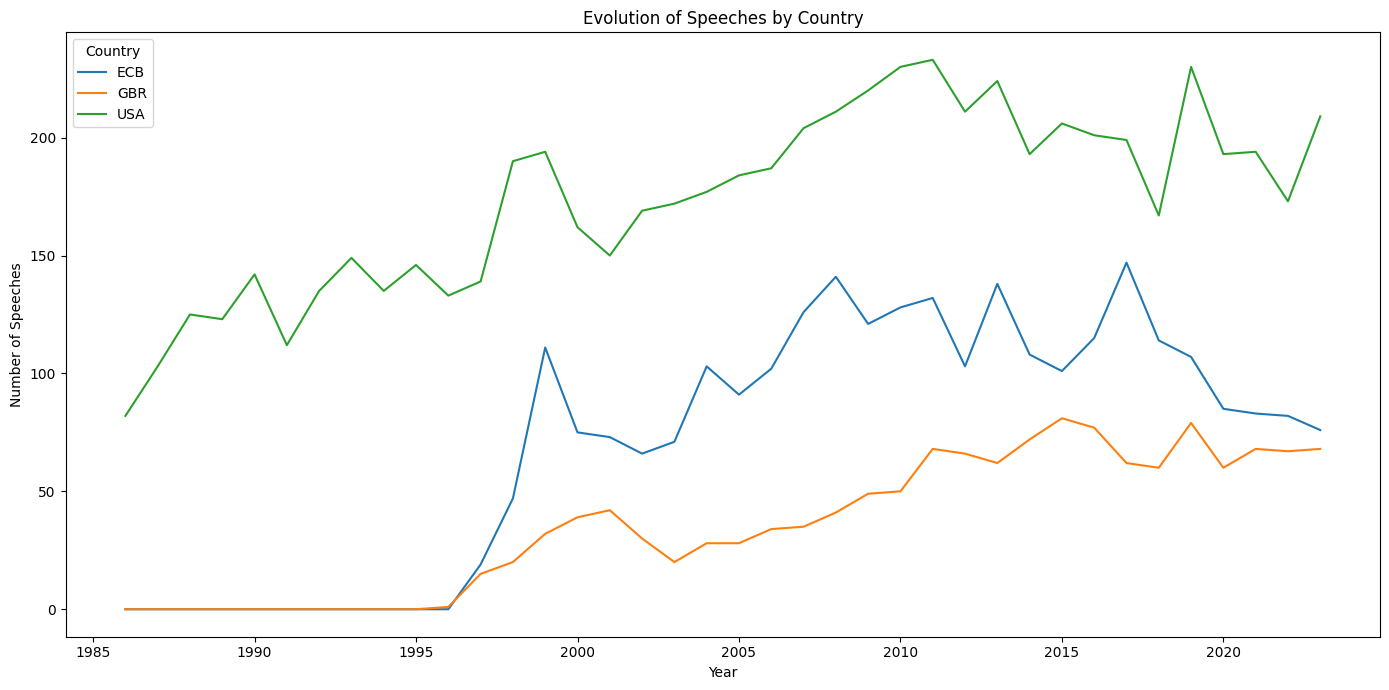

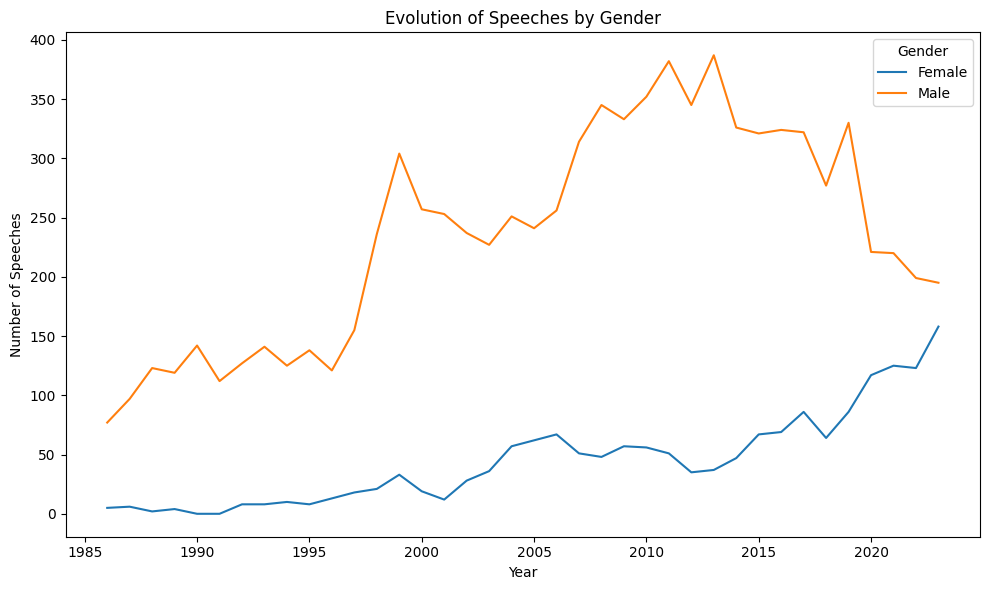

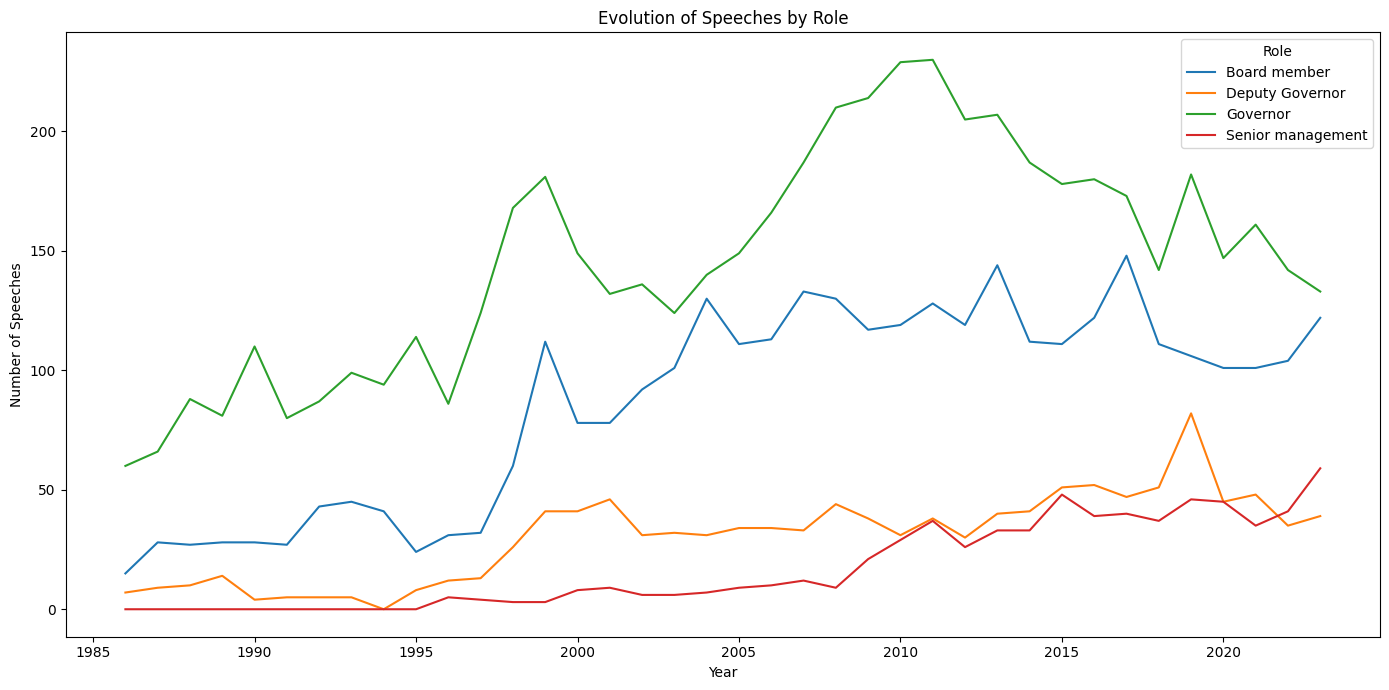

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = specialized_speeches_filtered.copy()
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])

df['Year'] = df['Date'].dt.year

for col in ['Country', 'Gender', 'Role']:
    df[col] = df[col].astype(str).str.strip()

top_countries = df['Country'].value_counts().index
top_roles = df['Role'].value_counts().index

df_country = df[df['Country'].isin(top_countries)]
df_role = df[df['Role'].isin(top_roles)]

# Country evolution
country_year = df_country.groupby(['Year', 'Country']).size().unstack(fill_value=0)
plt.figure(figsize=(14, 7))
country_year.plot(ax=plt.gca())
plt.title('Evolution of Speeches by Country')
plt.xlabel('Year')
plt.ylabel('Number of Speeches')
plt.tight_layout()
plt.show()

# Gender evolution
gender_year = df.groupby(['Year', 'Gender']).size().unstack(fill_value=0)
plt.figure(figsize=(10, 6))
gender_year.plot(ax=plt.gca())
plt.title('Evolution of Speeches by Gender')
plt.xlabel('Year')
plt.ylabel('Number of Speeches')
plt.tight_layout()
plt.show()

# Role evolution
role_year = df_role.groupby(['Year', 'Role']).size().unstack(fill_value=0)
plt.figure(figsize=(14, 7))
role_year.plot(ax=plt.gca())
plt.title('Evolution of Speeches by Role')
plt.xlabel('Year')
plt.ylabel('Number of Speeches')
plt.tight_layout()
plt.show()


What about document's lenght ?

In [12]:
# Clean text column (important!)
df['text'] = df['text'].astype(str)
# Create total_words variable
df['total_words'] = df['text'].str.split().str.len()

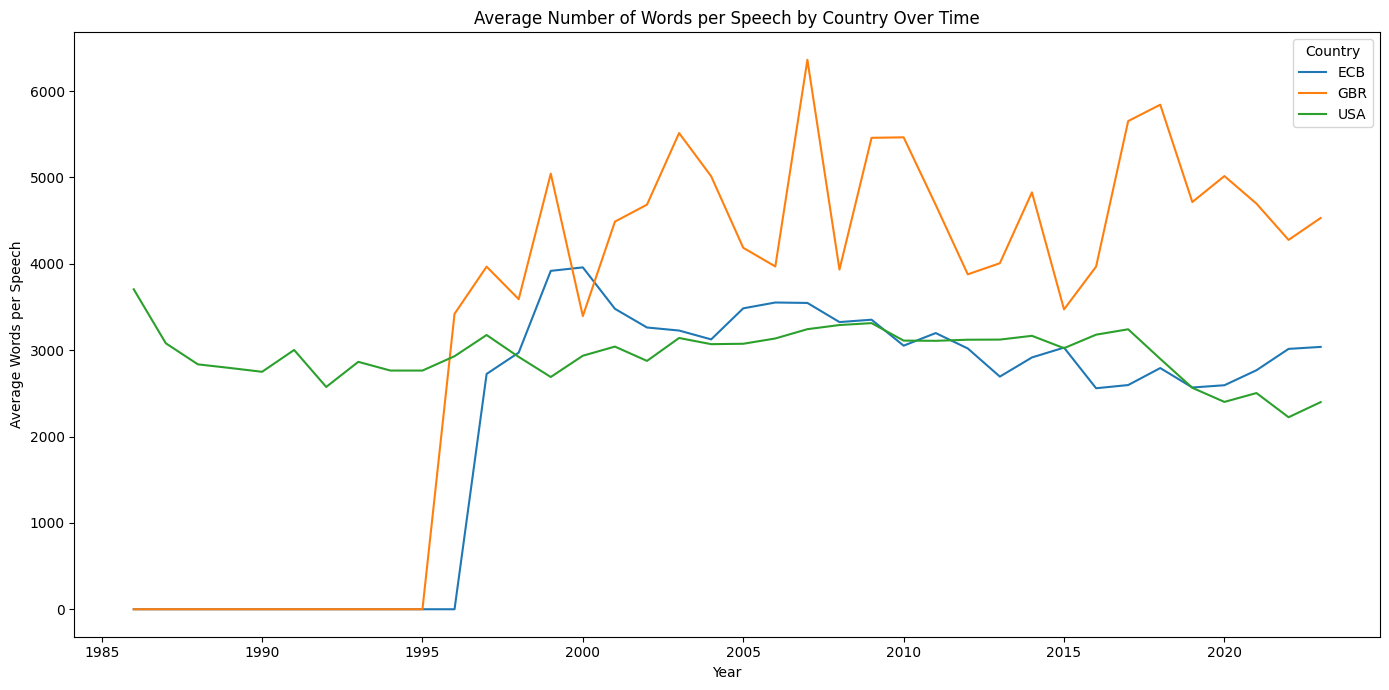

In [13]:
words_year_country = (
    df.groupby(['Year', 'Country'])['total_words']
    .mean()
    .unstack(fill_value=0)
)

plt.figure(figsize=(14, 7))
words_year_country.plot(ax=plt.gca())

plt.title('Average Number of Words per Speech by Country Over Time')
plt.xlabel('Year')
plt.ylabel('Average Words per Speech')
plt.tight_layout()
plt.show()

So the speeches seem to be shorter across time (except for the UK). Now, how readable are they ? I start to study leaxical readability metrics (such as the Flesch-Kincaid scores which are widely used over the literature). However, as the International monetary fund working paper of june 2025 points out, although this metric **do** offer some general insights, it is unable to *capture the semantic content of communication (including the underlying economic rationale, policy intent or strategic framing)*. To get more insights, we will have to delve into a more in-depth analysis, using NLP tools.  

In [ ]:
pip install textstat

In [13]:
import textstat
df['total_words'] = df['text'].apply(textstat.lexicon_count)
df['total_sentences'] = df['text'].apply(textstat.sentence_count)
df['total_syllables'] = df['text'].apply(textstat.syllable_count)

df['syllables_per_word'] = df['total_syllables'] / df['total_words']
df['words_per_sentence'] = df['total_words'] / df['total_sentences']

# Flesch Reading Ease (direct from package)
df['flesch_reading_ease'] = df['text'].apply(textstat.flesch_reading_ease)

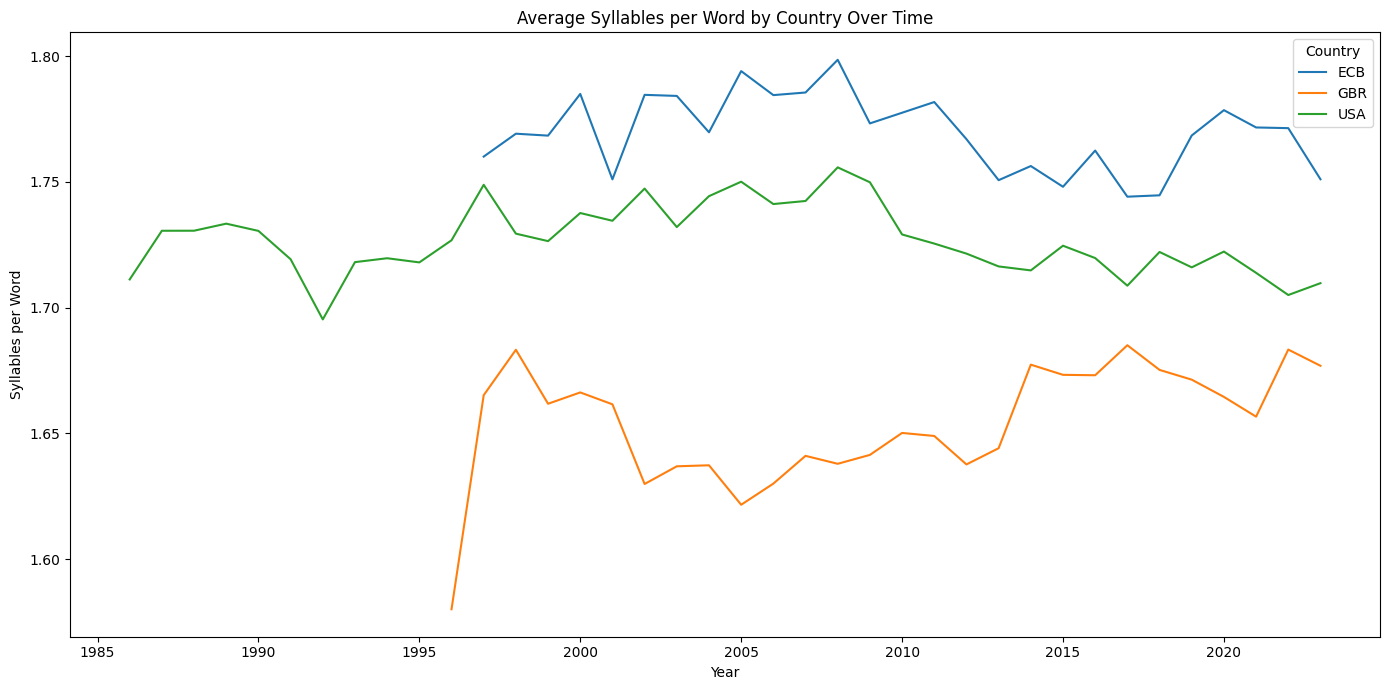

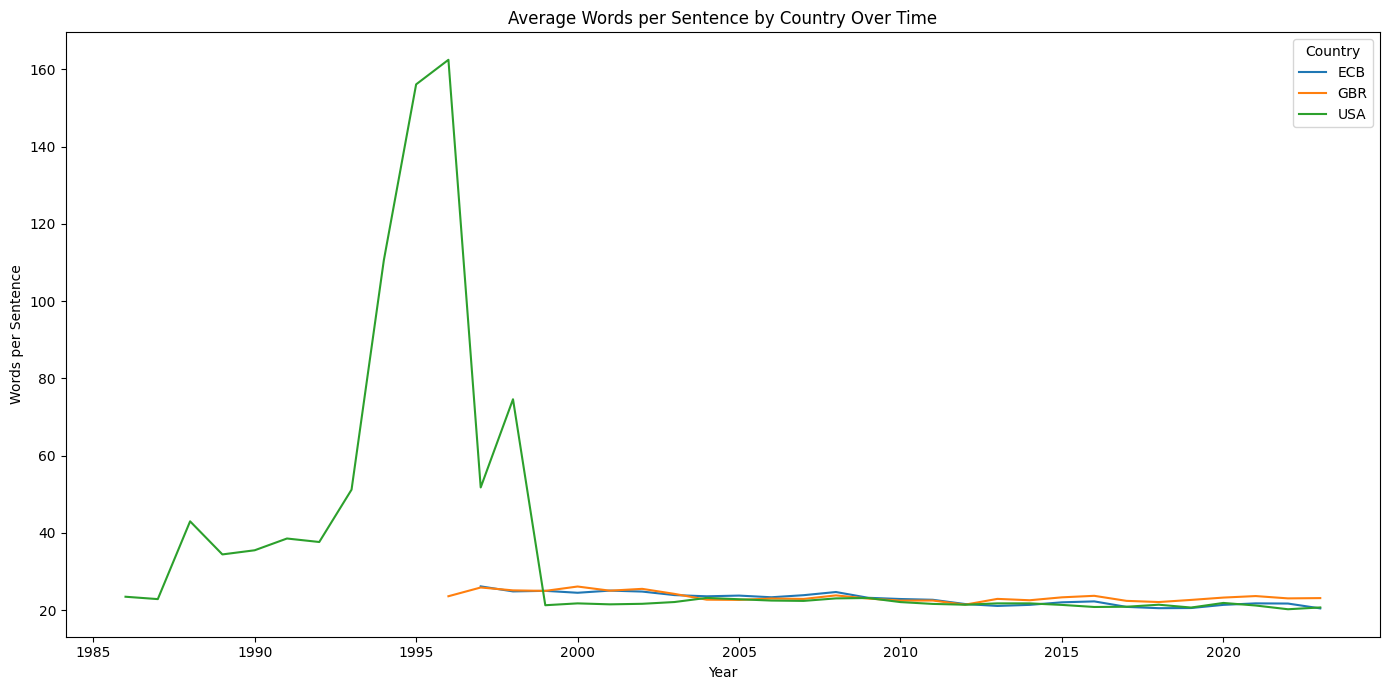

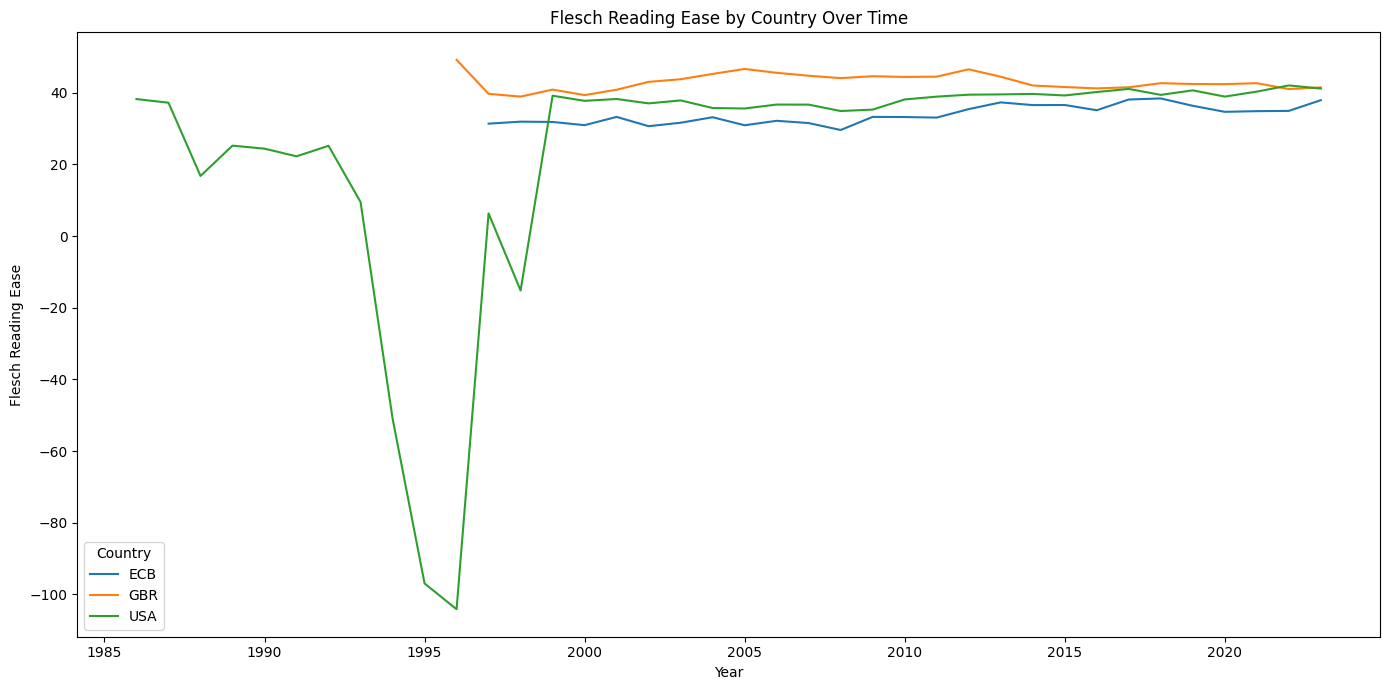

In [22]:
#Graph 1 : Syllabes per words by country
syllables_country_year = (
    df.groupby(['Year', 'Country'])['syllables_per_word']
    .mean()
    .unstack()
)

plt.figure(figsize=(14, 7))
syllables_country_year.plot(ax=plt.gca())

plt.title('Average Syllables per Word by Country Over Time')
plt.xlabel('Year')
plt.ylabel('Syllables per Word')
plt.tight_layout()
plt.show()

#Graph 2: Words per sentence by country 
wps_country_year = (
    df.groupby(['Year', 'Country'])['words_per_sentence']
    .mean()
    .unstack()
)

plt.figure(figsize=(14, 7))
wps_country_year.plot(ax=plt.gca())

plt.title('Average Words per Sentence by Country Over Time')
plt.xlabel('Year')
plt.ylabel('Words per Sentence')
plt.tight_layout()
plt.show()

#Graph 3: Flesch Reading Ease
flesch_country_year = (
    df.groupby(['Year', 'Country'])['flesch_reading_ease']
    .mean()
    .unstack()
)

plt.figure(figsize=(14, 7))
flesch_country_year.plot(ax=plt.gca())

plt.title('Flesch Reading Ease by Country Over Time')
plt.xlabel('Year')
plt.ylabel('Flesch Reading Ease')
plt.tight_layout()
plt.show()

The Flesch-Kincaid Ease Score is calculated as:
$$
\text{Score } = 206.835-1.015(\frac{\text{ Total Words }}{\text{ Total Sentences }})-84.6(\frac{\text{ Total Syllables }}{\text{ Total Words }})
$$
The score ranges from 0 to 100, with higher values indicating better readability. In English-language texts, scores above 60 correspond to an 8th-grade reading level, while values between 30 and 50 suggest college-level complexity. Scores below 30 indicate highly technical or specialized content.

In [14]:
import pydantic
import spacy
import thinc

print("pydantic:", pydantic.__version__)
print("spacy:", spacy.__version__)
print("thinc:", thinc.__version__)

nlp = spacy.load("en_core_web_sm")
print("OK")

pydantic: 2.12.5
spacy: 3.8.11
thinc: 8.3.11
OK


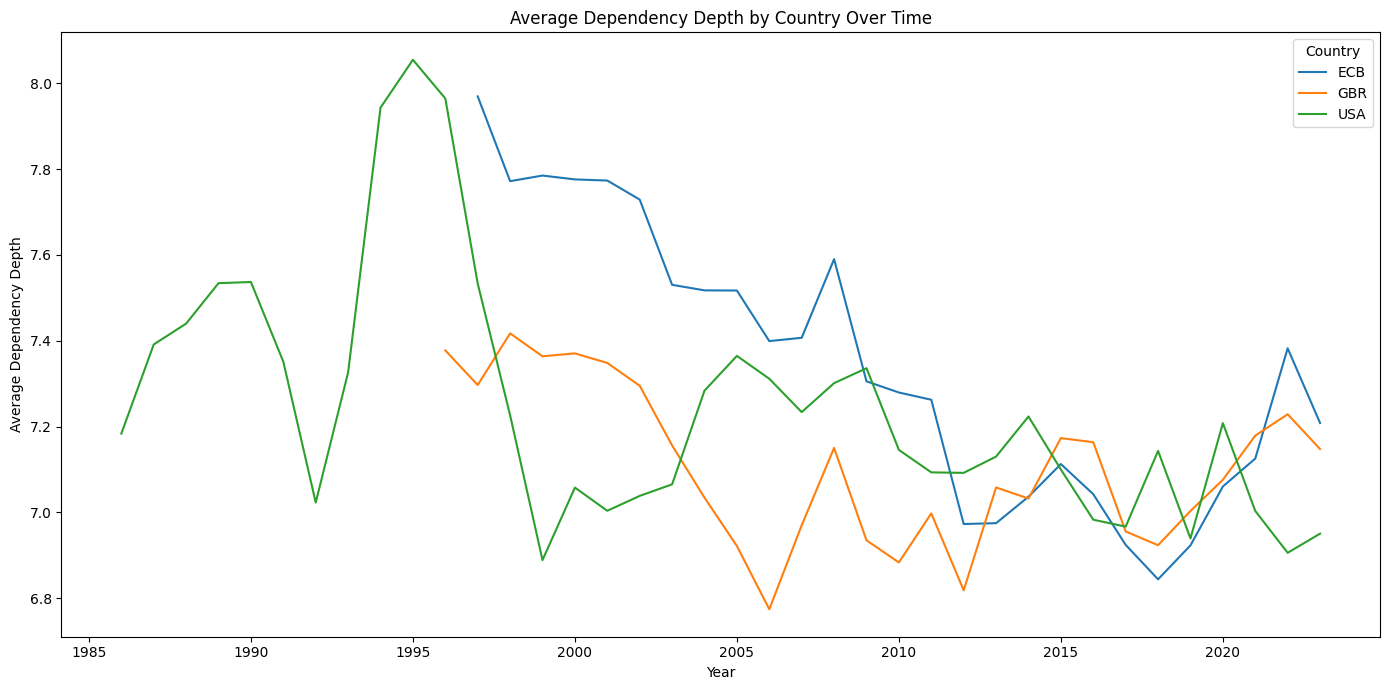

In [16]:

# -----------------------------
# 3. Function to compute dependency depth of one sentence
# -----------------------------
def sentence_dependency_depth(sent):
    """
    Depth = longest path from sentence root to any terminal node (leaf).
    We count nodes on the path, so a root->child->grandchild path has depth 3.
    """
    root = sent.root

    def depth_from_token(token):
        children = list(token.children)
        if not children:
            return 1
        return 1 + max(depth_from_token(child) for child in children)

    return depth_from_token(root)

# -----------------------------
# 4. Function to compute speech-level dependency depth
# -----------------------------
def speech_dependency_depth(text):
    """
    Compute average sentence dependency depth for one speech.
    You could also use max(sentence depths) instead of mean if preferred.
    """
    doc = nlp(text)

    sentence_depths = []
    for sent in doc.sents:
        # skip extremely short / empty-like sentences
        sent_tokens = [tok for tok in sent if not tok.is_space]
        if len(sent_tokens) == 0:
            continue
        sentence_depths.append(sentence_dependency_depth(sent))

    if len(sentence_depths) == 0:
        return None

    return sum(sentence_depths) / len(sentence_depths)

# -----------------------------
# 5. Compute dependency depth for each speech
# -----------------------------
df['dependency_depth'] = df['text'].apply(speech_dependency_depth)

# Drop rows where parsing failed
df = df.dropna(subset=['dependency_depth'])

# -----------------------------
# 6. Aggregate by year and country
# -----------------------------
depth_year_country = (
    df.groupby(['Year', 'Country'])['dependency_depth']
    .mean()
    .unstack()
)

# -----------------------------
# 7. Plot
# -----------------------------
plt.figure(figsize=(14, 7))
depth_year_country.plot(ax=plt.gca())

plt.title('Average Dependency Depth by Country Over Time')
plt.xlabel('Year')
plt.ylabel('Average Dependency Depth')
plt.tight_layout()
plt.show()